- Nombre: Erika Judith Paco Suca
- Codigo: 2017-119037

Importar Librerías Necesarias

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from PIL import Image
from PIL import ImageOps

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)



100%|██████████| 9.91M/9.91M [00:00<00:00, 12.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 337kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.40MB/s]


In [3]:
# Definir modelo CNN
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout = nn.Dropout(0.5)

        self._to_linear = None
        x = torch.randn(1, 1, 28, 28)
        self._forward_features(x)

        self.fc1 = nn.Linear(self._to_linear, 128)
        self.fc2 = nn.Linear(128, 10)

    def _forward_features(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.max_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, 2)
        if self._to_linear is None:
            self._to_linear = x[0].shape[0] * x[0].shape[1] * x[0].shape[2]
        return x

    def forward(self, x):
        x = self._forward_features(x)
        x = x.view(-1, self._to_linear)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

model = CNN().to(device)


In [4]:

# Función de entrenamiento
def train_model(model, epochs=15):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_acc = 0
    for epoch in range(epochs):

        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        print(f'Epoch {epoch+1}/{epochs} | '
              f'Train Loss: {train_loss/len(train_loader):.3f} | '
              f'Val Loss: {val_loss/len(val_loader):.3f} | '
              f'Val Acc: {val_acc:.2f}%')

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'mnist_cnn.pth')

    print(f'Mejor precisión en validación: {best_acc:.2f}%')

train_model(model)


Epoch 1/15 | Train Loss: 0.417 | Val Loss: 0.139 | Val Acc: 95.72%
Epoch 2/15 | Train Loss: 0.161 | Val Loss: 0.086 | Val Acc: 97.42%
Epoch 3/15 | Train Loss: 0.123 | Val Loss: 0.067 | Val Acc: 97.88%
Epoch 4/15 | Train Loss: 0.108 | Val Loss: 0.057 | Val Acc: 98.28%
Epoch 5/15 | Train Loss: 0.093 | Val Loss: 0.059 | Val Acc: 98.29%
Epoch 6/15 | Train Loss: 0.089 | Val Loss: 0.057 | Val Acc: 98.18%
Epoch 7/15 | Train Loss: 0.084 | Val Loss: 0.045 | Val Acc: 98.63%
Epoch 8/15 | Train Loss: 0.081 | Val Loss: 0.045 | Val Acc: 98.52%
Epoch 9/15 | Train Loss: 0.074 | Val Loss: 0.044 | Val Acc: 98.50%
Epoch 10/15 | Train Loss: 0.071 | Val Loss: 0.044 | Val Acc: 98.57%
Epoch 11/15 | Train Loss: 0.068 | Val Loss: 0.037 | Val Acc: 98.94%
Epoch 12/15 | Train Loss: 0.066 | Val Loss: 0.055 | Val Acc: 98.35%
Epoch 13/15 | Train Loss: 0.064 | Val Loss: 0.039 | Val Acc: 98.73%
Epoch 14/15 | Train Loss: 0.065 | Val Loss: 0.035 | Val Acc: 98.91%
Epoch 15/15 | Train Loss: 0.062 | Val Loss: 0.035 | Val A

In [5]:
def predict_image(image_path, model_path='mnist_cnn.pth'):
    model = CNN().to(device)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    image = Image.open(image_path).convert('L')
    image = ImageOps.invert(image)
    transform = transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1).cpu().numpy().squeeze()

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image_tensor.cpu().squeeze().numpy(), cmap='gray')
    plt.axis('on')

    plt.subplot(1, 2, 2)
    plt.bar(range(10), probabilities)
    plt.xticks(range(10))
    plt.title('Probabilidades por clase')
    plt.xlabel('Dígito')
    plt.ylabel('Probabilidad')
    plt.ylim([0, 1])

    predicted_class = probabilities.argmax()
    print(f'Clase predicha: {predicted_class} con {probabilities[predicted_class]*100:.2f}% de confianza')
    plt.show()


In [10]:
!git clone https://github.com/Erikao4/mnist_limites_cnn.git
!apt-get install p7zip-full
!7z x /content/mnist_limites_cnn/limites_cnn_erika.7z

Cloning into 'mnist_limites_cnn'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), 924.20 KiB | 18.86 MiB/s, done.


--- Probando caso: normales ---
Clase predicha: 1 con 13.56% de confianza


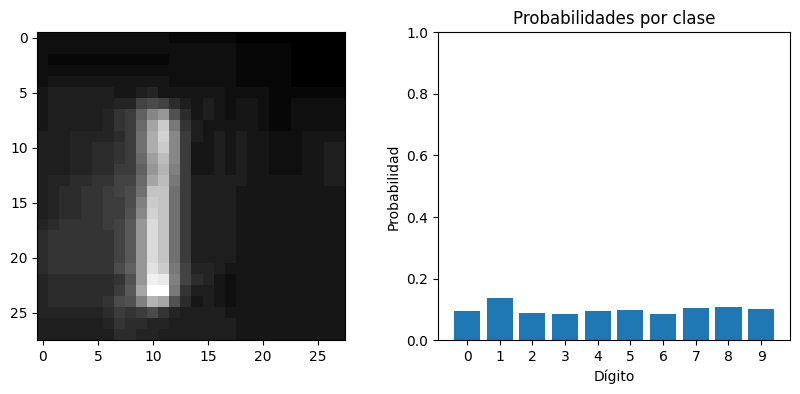

Clase predicha: 2 con 16.69% de confianza


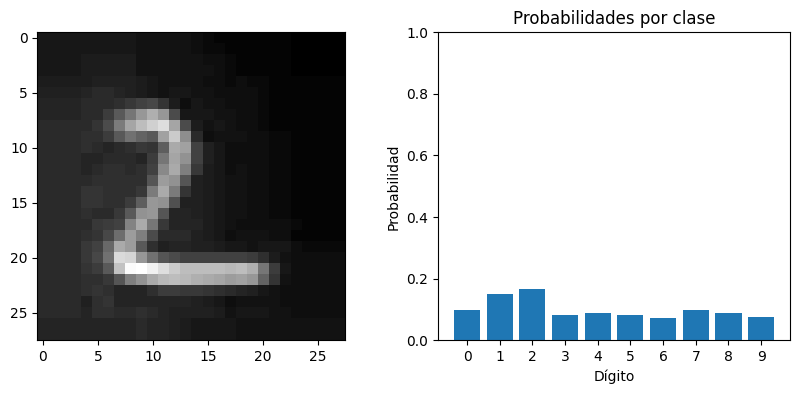

Clase predicha: 3 con 18.46% de confianza


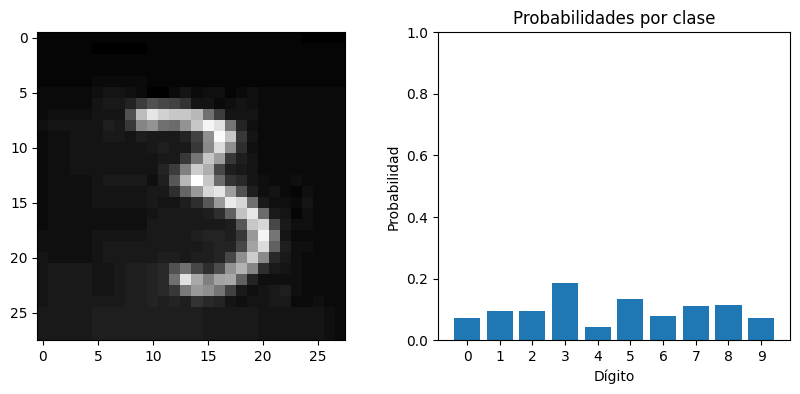

Clase predicha: 4 con 17.62% de confianza


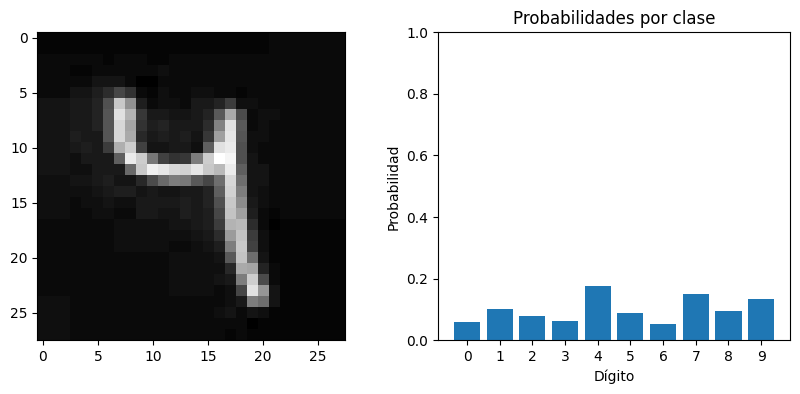

Clase predicha: 5 con 16.99% de confianza


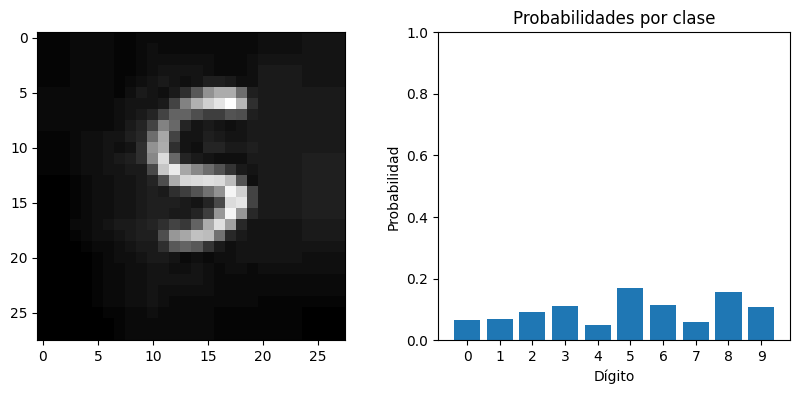

Clase predicha: 8 con 16.61% de confianza


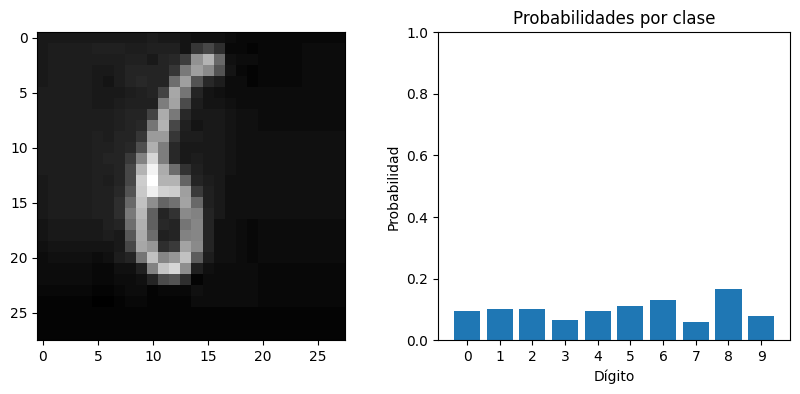

Clase predicha: 7 con 18.91% de confianza


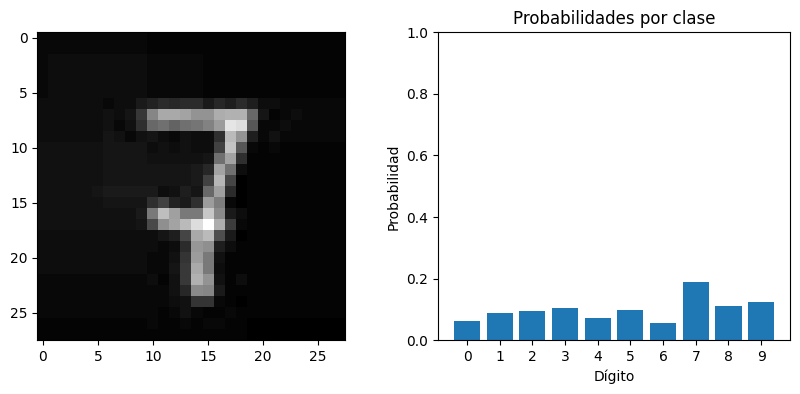

Clase predicha: 8 con 18.70% de confianza


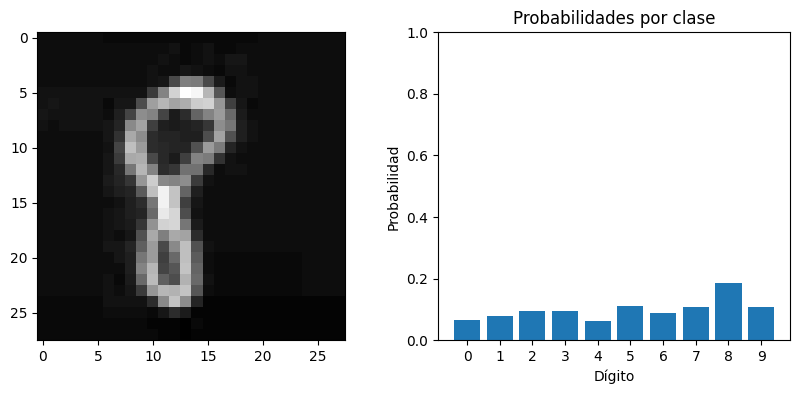

Clase predicha: 9 con 13.47% de confianza


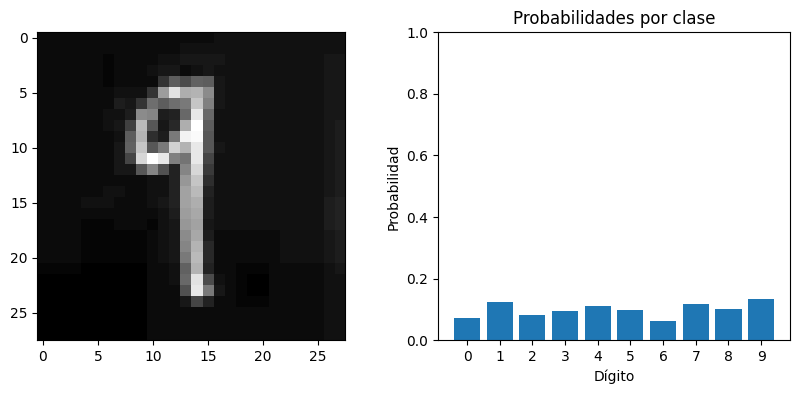

Error procesando /content/mnist_limites_cnn/limites_cnn/normales/10.png: [Errno 2] No such file or directory: '/content/mnist_limites_cnn/limites_cnn/normales/10.png'
--- Probando caso: no_digitos ---
Clase predicha: 8 con 16.62% de confianza


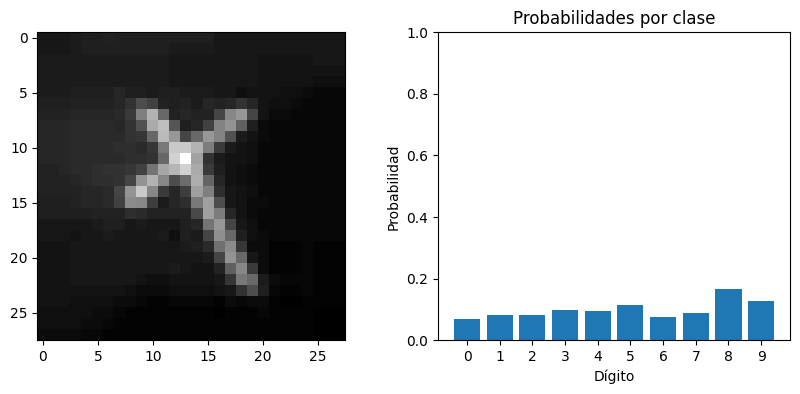

Clase predicha: 5 con 19.86% de confianza


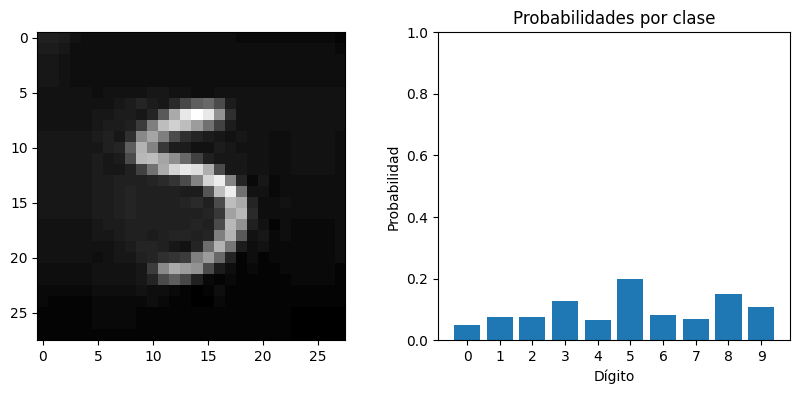

Clase predicha: 4 con 16.55% de confianza


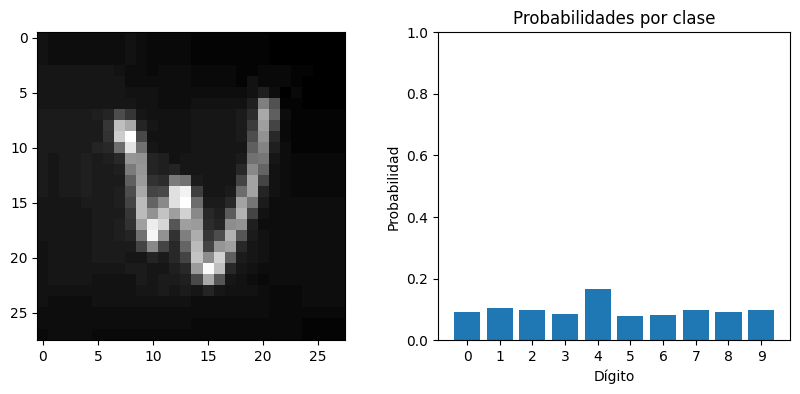

Clase predicha: 4 con 26.73% de confianza


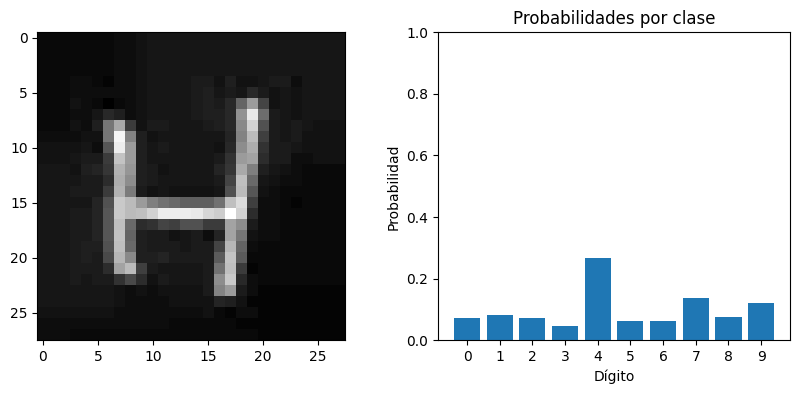

Clase predicha: 5 con 17.52% de confianza


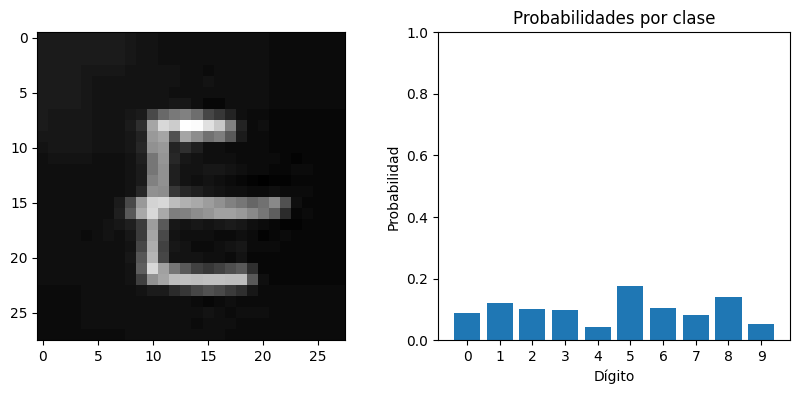

Clase predicha: 1 con 20.92% de confianza


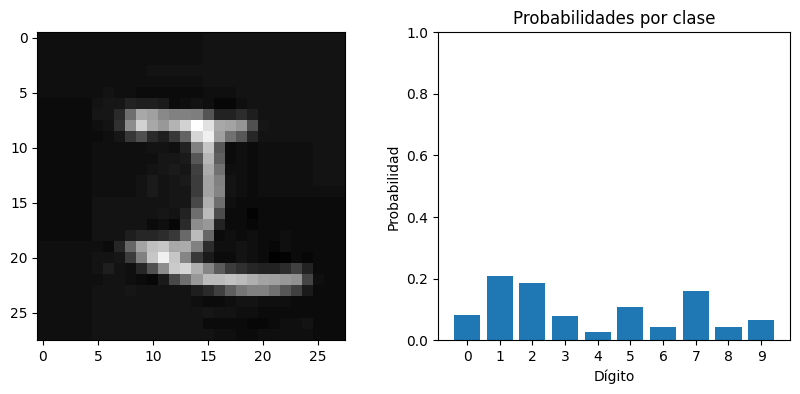

Clase predicha: 1 con 20.90% de confianza


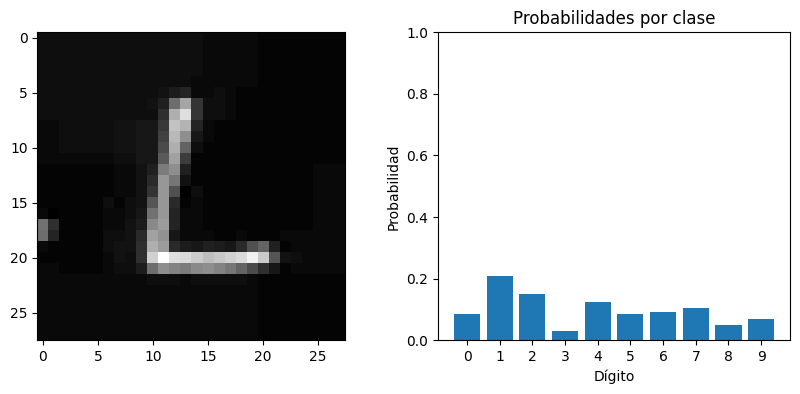

Clase predicha: 4 con 15.58% de confianza


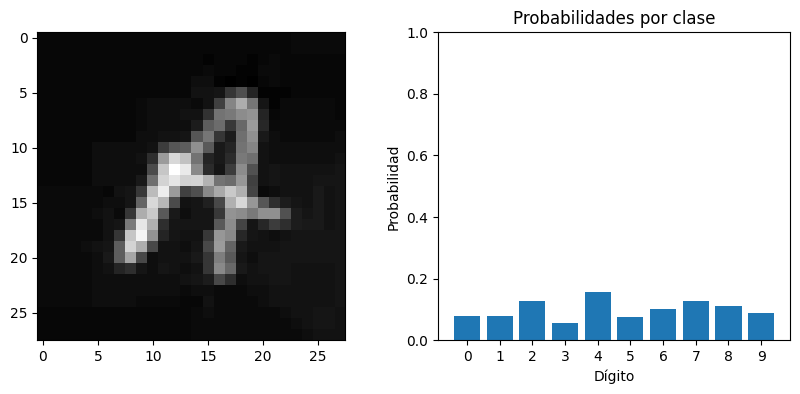

Clase predicha: 7 con 13.06% de confianza


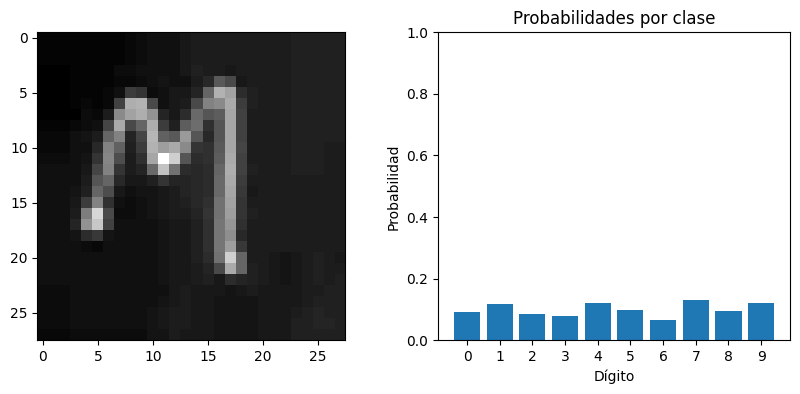

Error procesando /content/mnist_limites_cnn/limites_cnn/no_digitos/10.png: [Errno 2] No such file or directory: '/content/mnist_limites_cnn/limites_cnn/no_digitos/10.png'
--- Probando caso: rotacion ---
Clase predicha: 7 con 12.33% de confianza


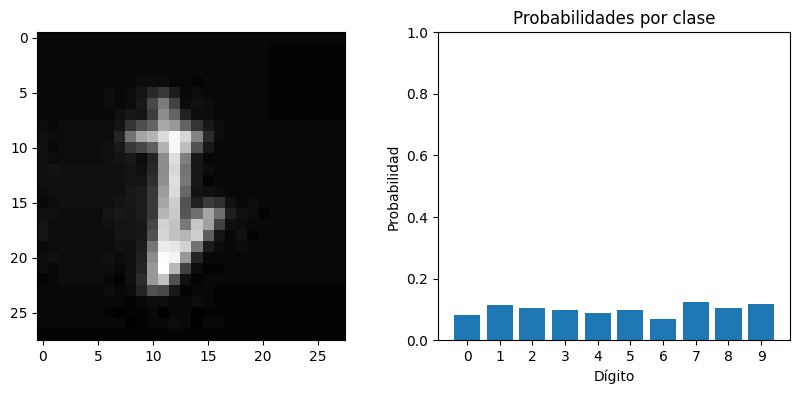

Clase predicha: 7 con 13.55% de confianza


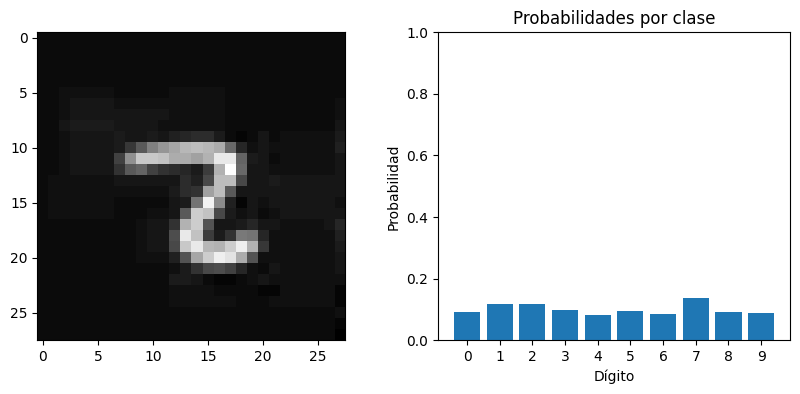

Clase predicha: 1 con 13.00% de confianza


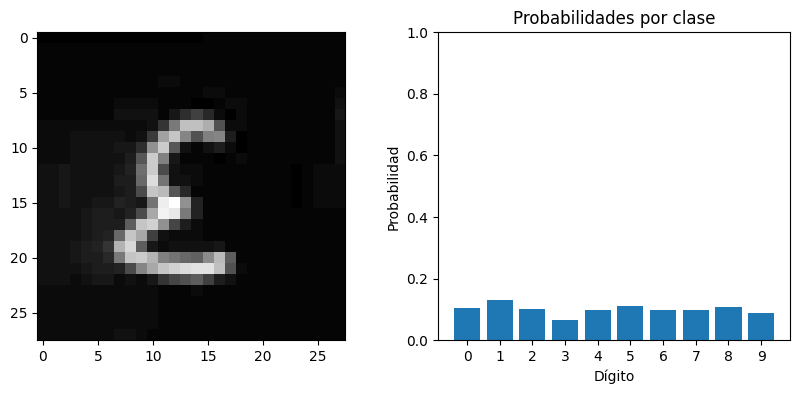

Clase predicha: 1 con 11.89% de confianza


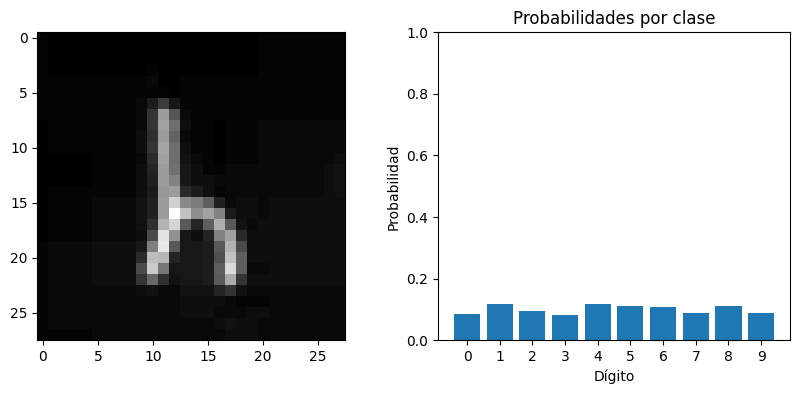

Clase predicha: 5 con 15.43% de confianza


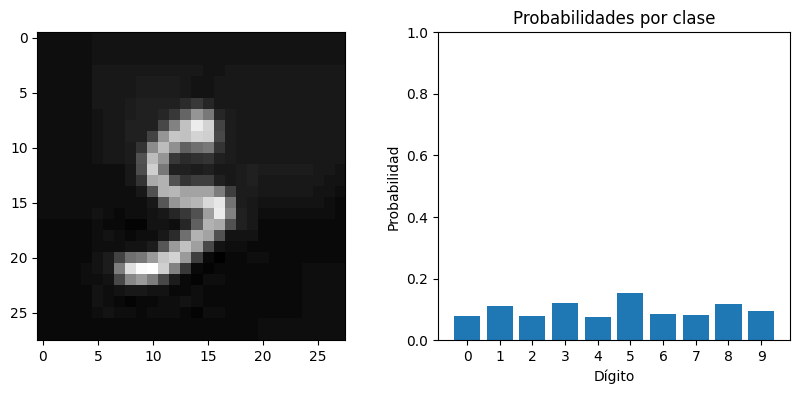

Clase predicha: 9 con 13.84% de confianza


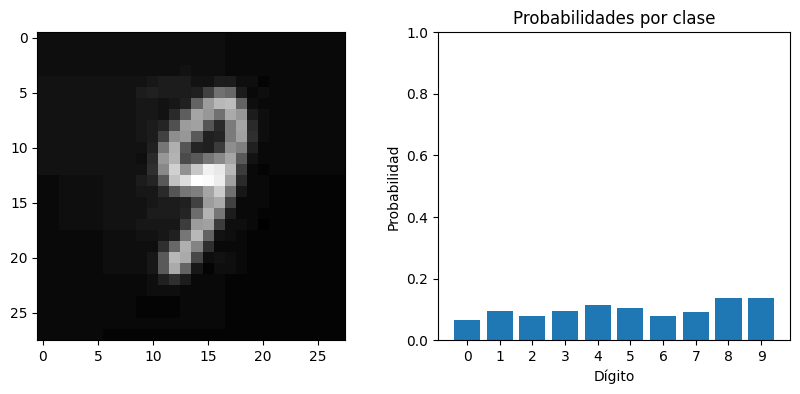

Clase predicha: 1 con 14.34% de confianza


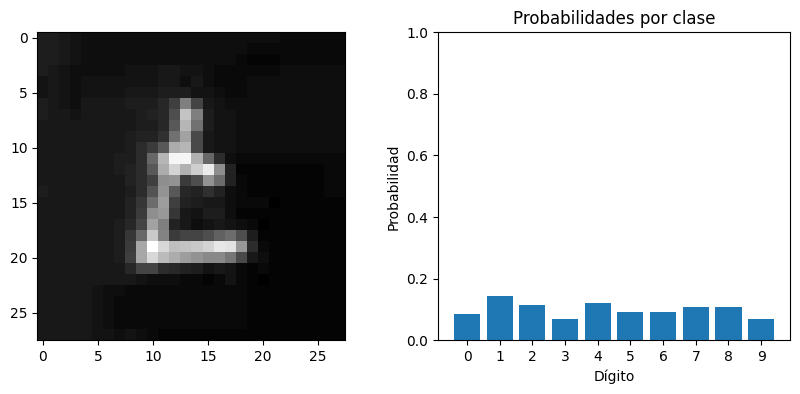

Clase predicha: 8 con 19.21% de confianza


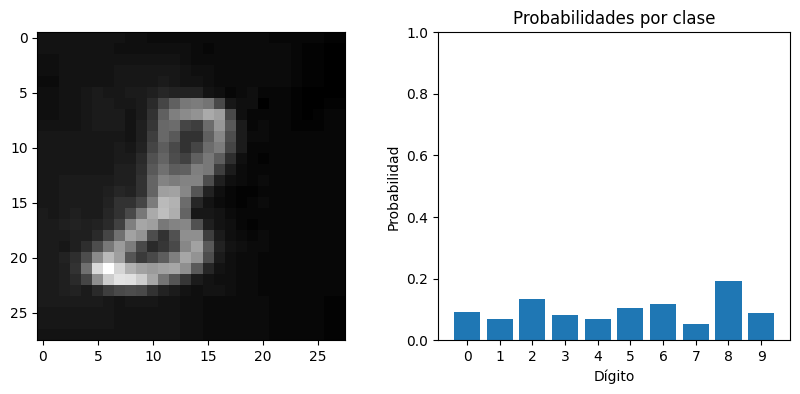

Clase predicha: 6 con 13.11% de confianza


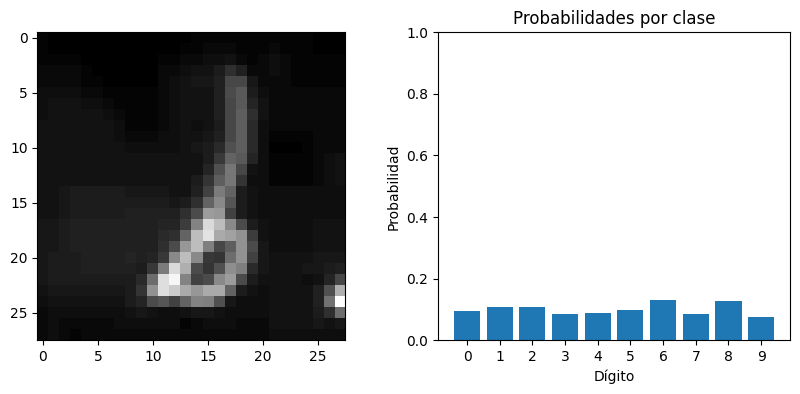

Error procesando /content/mnist_limites_cnn/limites_cnn/rotacion/10.png: [Errno 2] No such file or directory: '/content/mnist_limites_cnn/limites_cnn/rotacion/10.png'
--- Probando caso: borrones ---
Clase predicha: 8 con 17.11% de confianza


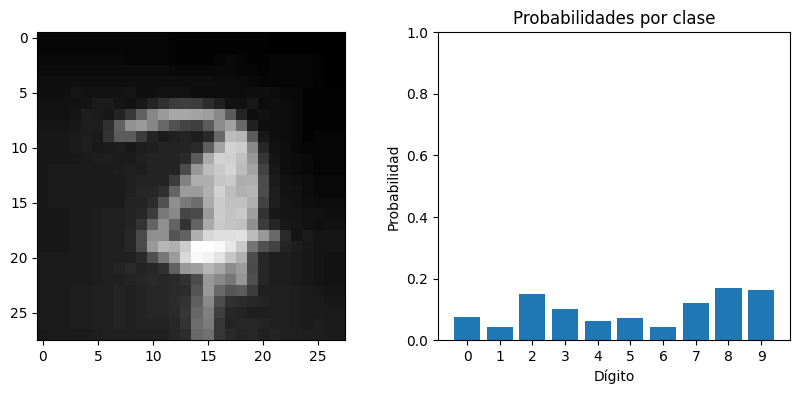

Clase predicha: 3 con 22.73% de confianza


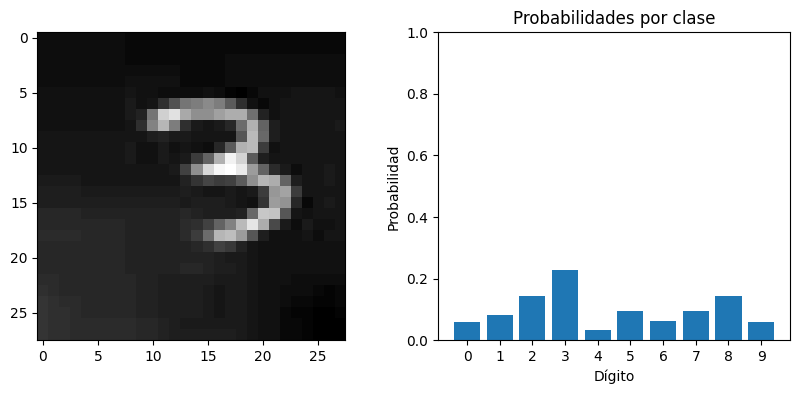

Clase predicha: 6 con 18.86% de confianza


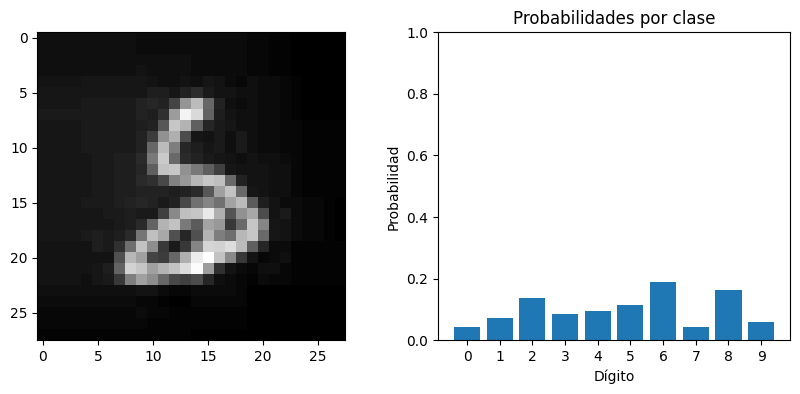

Clase predicha: 6 con 16.49% de confianza


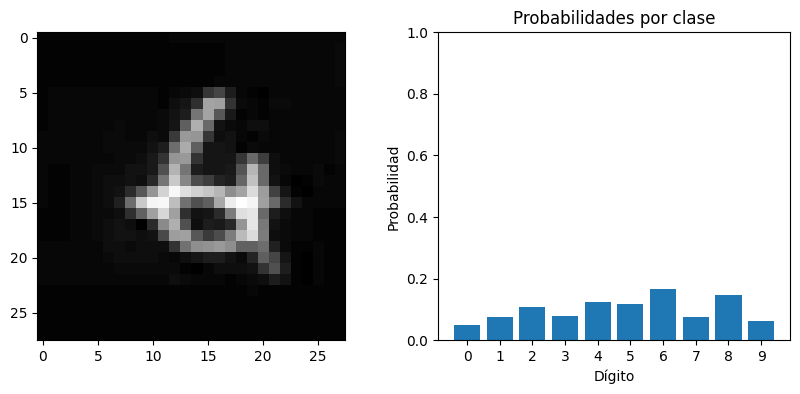

Clase predicha: 8 con 21.77% de confianza


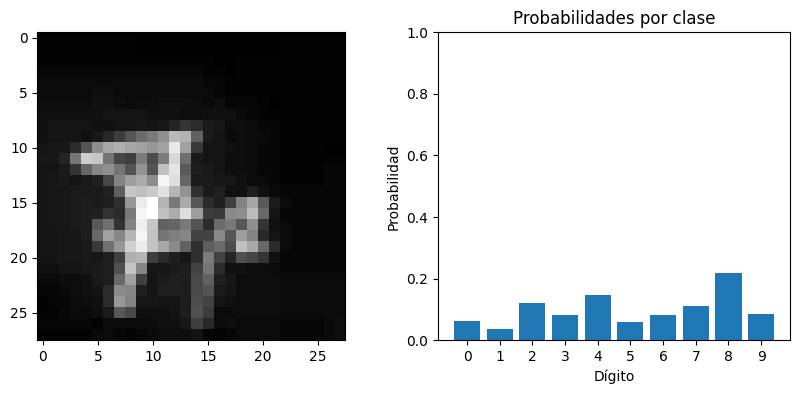

Clase predicha: 8 con 20.27% de confianza


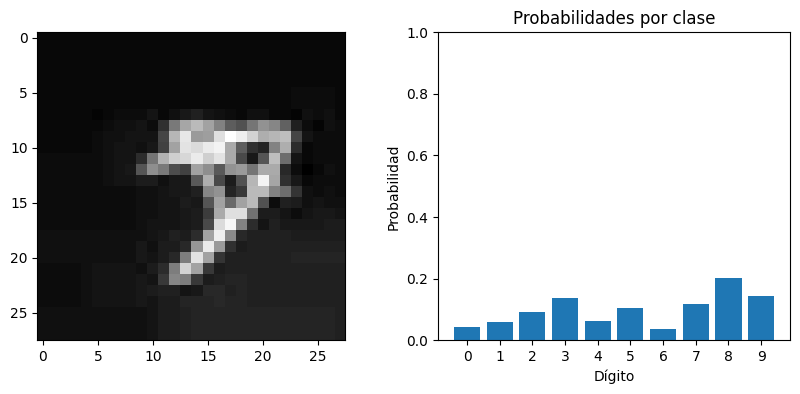

Clase predicha: 9 con 20.47% de confianza


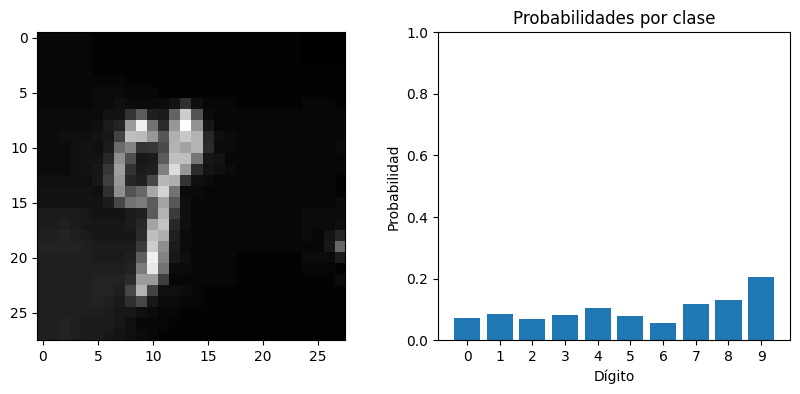

Clase predicha: 1 con 18.94% de confianza


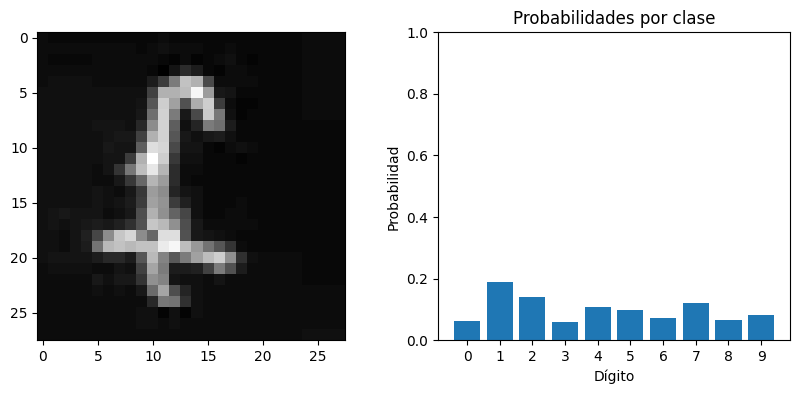

Error procesando /content/mnist_limites_cnn/limites_cnn/borrones/9.png: [Errno 2] No such file or directory: '/content/mnist_limites_cnn/limites_cnn/borrones/9.png'
Error procesando /content/mnist_limites_cnn/limites_cnn/borrones/10.png: [Errno 2] No such file or directory: '/content/mnist_limites_cnn/limites_cnn/borrones/10.png'
--- Probando caso: ruido ---
Clase predicha: 8 con 45.85% de confianza


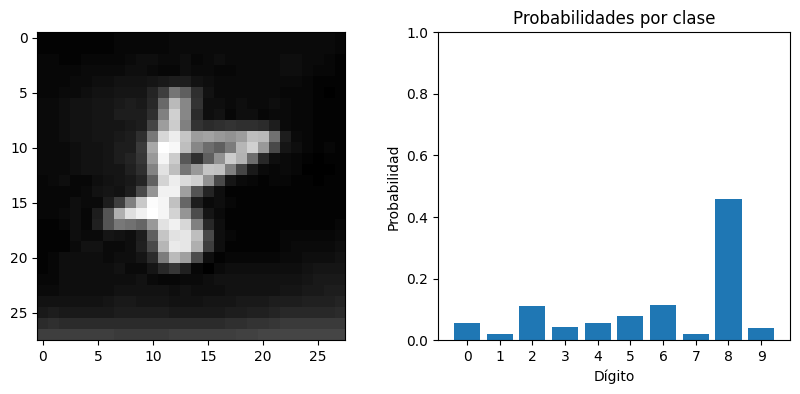

Clase predicha: 8 con 33.73% de confianza


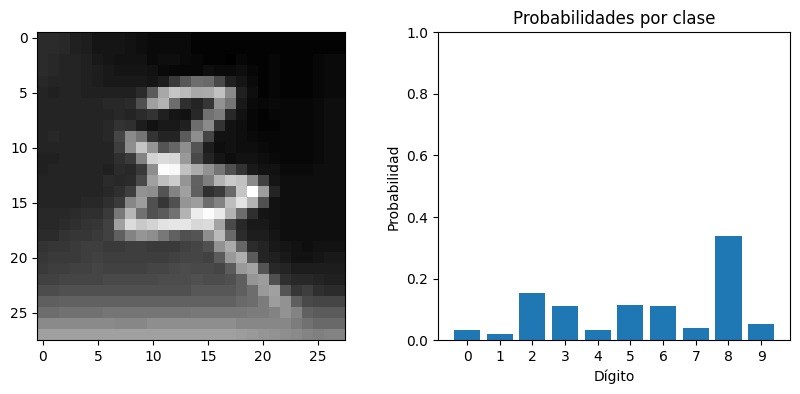

Clase predicha: 8 con 29.66% de confianza


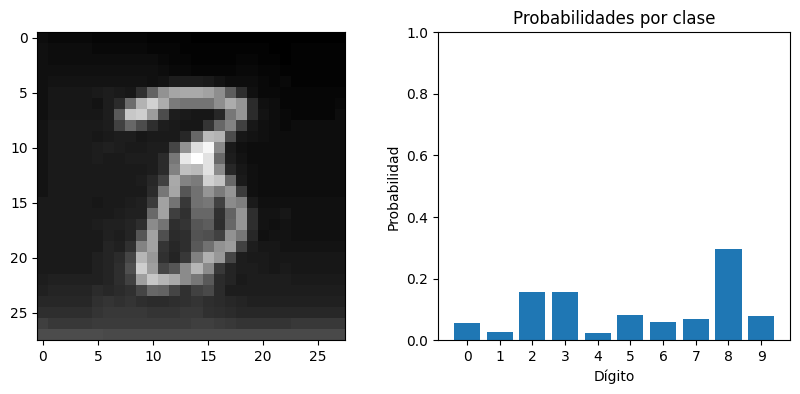

Clase predicha: 8 con 20.92% de confianza


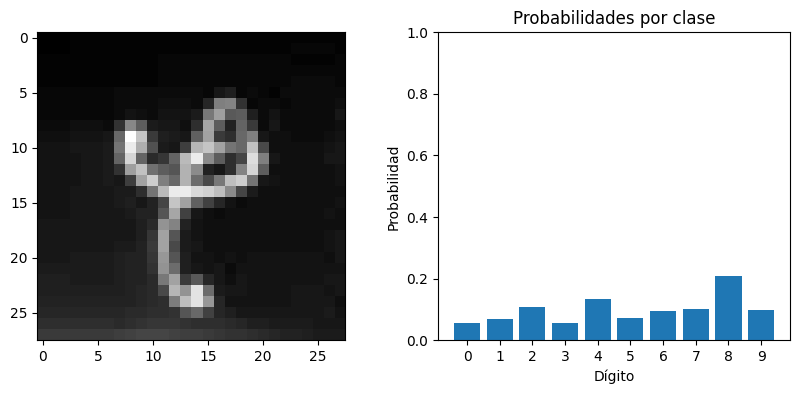

Clase predicha: 8 con 51.40% de confianza


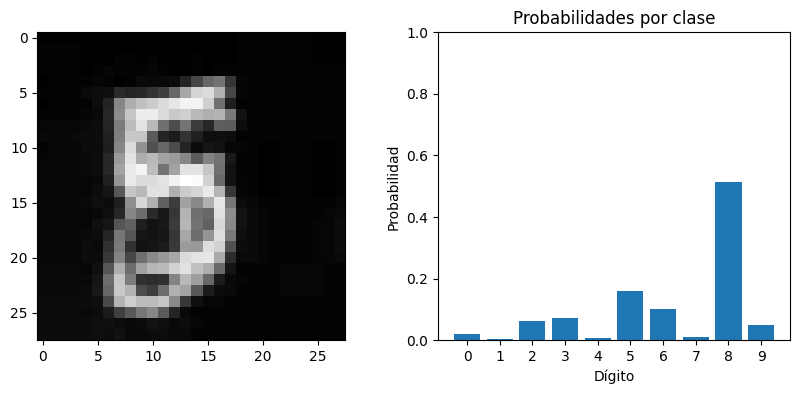

Clase predicha: 6 con 19.31% de confianza


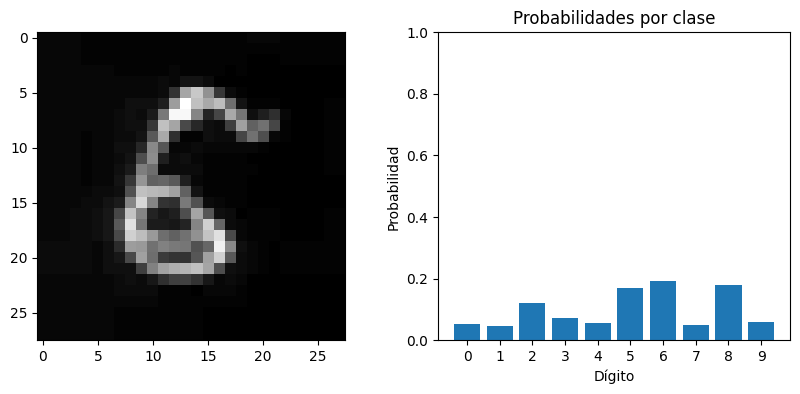

Clase predicha: 8 con 31.18% de confianza


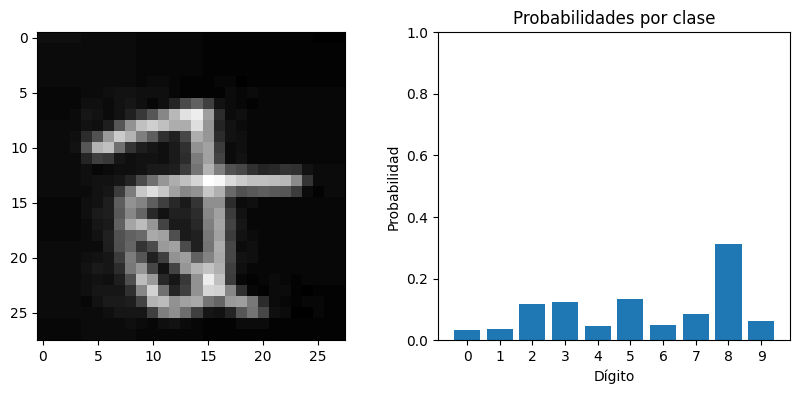

Clase predicha: 8 con 26.24% de confianza


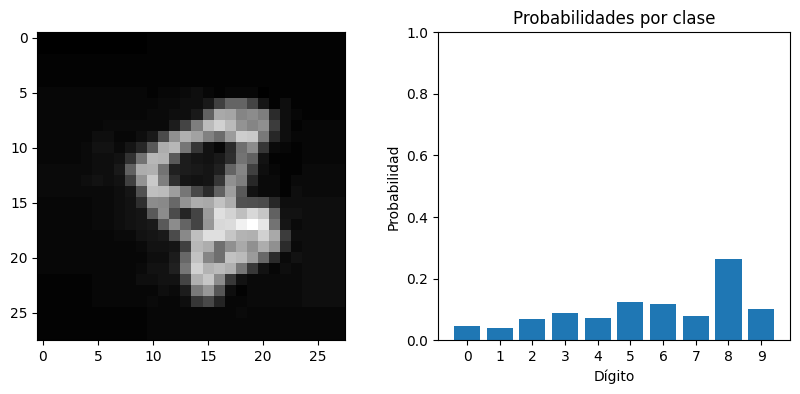

Clase predicha: 8 con 16.78% de confianza


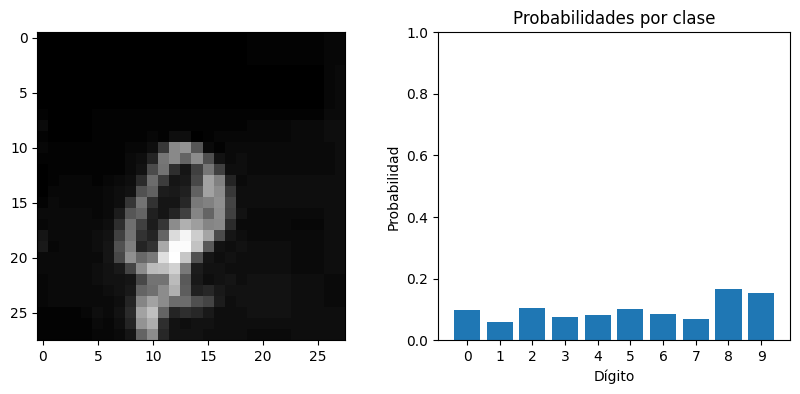

Error procesando /content/mnist_limites_cnn/limites_cnn/ruido/10.png: [Errno 2] No such file or directory: '/content/mnist_limites_cnn/limites_cnn/ruido/10.png'


In [22]:
test_cases = [
    'normales', 'no_digitos',
    'rotacion', 'borrones',
    'ruido'
]

base_path = '/content/mnist_limites_cnn/limites_cnn/'

for case in test_cases:
    print(f'--- Probando caso: {case} ---')
    for i in range(1, 11):
        image_path = os.path.join(base_path, case, f'{i}.png')
        try:
            predict_image(image_path, '/content/mnist_limites_cnn/limites_cnn/mnist_cnn.pth')
        except Exception as e:
            print(f'Error procesando {image_path}: {str(e)}')